In [8]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

API_URL = "https://samples.openweathermap.org/data/2.5/forecast/hourly?zip=70000&appid=b6907d289e10d714a6e88b30761fae22"

In [9]:
try:
    response = requests.get(API_URL) # Thực hiện phương thức GET để lấy dữ liệu 
    response.raise_for_status()  # Ném lỗi nếu yêu cầu không thành công (ví dụ: 404, 500)
    data = response.json()       # Đọc dữ liệu trả về ở dạng JSON 
    raw_data = data
except requests.exceptions.RequestException as e:
    print(f"Lỗi khi gọi API: {e}")
except ValueError as e: # Catch JSONDecodeError for older requests versions
    print(f"Lỗi khi giải mã JSON: {e}. Phản hồi API không phải JSON hợp lệ.")

In [10]:
raw_data

{'cod': '200',
 'message': 0.0208,
 'cnt': 96,
 'list': [{'dt': 1553709600,
   'main': {'temp': 286.44,
    'temp_min': 286.258,
    'temp_max': 286.44,
    'pressure': 1015.82,
    'sea_level': 1015.82,
    'grnd_level': 1002.193,
    'humidity': 100,
    'temp_kf': 0.18},
   'weather': [{'id': 500,
     'main': 'Rain',
     'description': 'light rain',
     'icon': '10d'}],
   'clouds': {'all': 86},
   'wind': {'speed': 5.51, 'deg': 202.816},
   'rain': {'1h': 0.812},
   'sys': {'pod': 'd'},
   'dt_txt': '2019-03-27 18:00:00'},
  {'dt': 1553713200,
   'main': {'temp': 286.43,
    'temp_min': 286.3,
    'temp_max': 286.43,
    'pressure': 1016.183,
    'sea_level': 1016.183,
    'grnd_level': 1002.667,
    'humidity': 100,
    'temp_kf': 0.13},
   'weather': [{'id': 500,
     'main': 'Rain',
     'description': 'light rain',
     'icon': '10d'}],
   'clouds': {'all': 92},
   'wind': {'speed': 4.84, 'deg': 206.141},
   'rain': {'1h': 0.625},
   'sys': {'pod': 'd'},
   'dt_txt': '2019-0

In [11]:
weather_list = raw_data['list']

parsed_data = []
for item in weather_list:
    try:
        dt_object = datetime.fromtimestamp(item['dt'])
        pressure = item['main']['pressure']
        wind_speed = item['wind']['speed']

        parsed_data.append({
            'date_time': dt_object,
            'date': dt_object.date(),
            'pressure': pressure,
            'wind_speed': wind_speed
        })
    except KeyError as e:
        print(f"Lỗi parsing dữ liệu: Thiếu khóa '{e}' trong một mục. Bỏ qua mục này.")
        continue
    except Exception as e:
        print(f"Lỗi không xác định khi xử lý mục: {e}. Bỏ qua mục này.")
        continue

df = pd.DataFrame(parsed_data)
df = df.sort_values(by='date_time')

In [12]:
df

,date_time,date,pressure,wind_speed
0,2019-03-28 01:00:00,2019-03-28,1015.820,5.51
1,2019-03-28 02:00:00,2019-03-28,1016.183,4.84
2,2019-03-28 03:00:00,2019-03-28,1016.462,4.58
3,2019-03-28 04:00:00,2019-03-28,1016.441,5.41
4,2019-03-28 05:00:00,2019-03-28,1016.312,5.71
...,...,...,...,...
91,2019-03-31 20:00:00,2019-03-31,1024.121,1.00
92,2019-03-31 21:00:00,2019-03-31,1024.185,0.92
93,2019-03-31 22:00:00,2019-03-31,1024.272,0.97
94,2019-03-31 23:00:00,2019-03-31,1024.177,1.35


In [14]:
if df.empty:
    print("Không có dữ liệu để vẽ biểu đồ.")

daily_summary_df = df.groupby('date').agg(
    avg_pressure=('pressure', 'mean'),
    avg_wind_speed=('wind_speed', 'mean')
).reset_index()

a) Vẽ biểu đồ áp suất không khí (pressure) theo từng ngày.

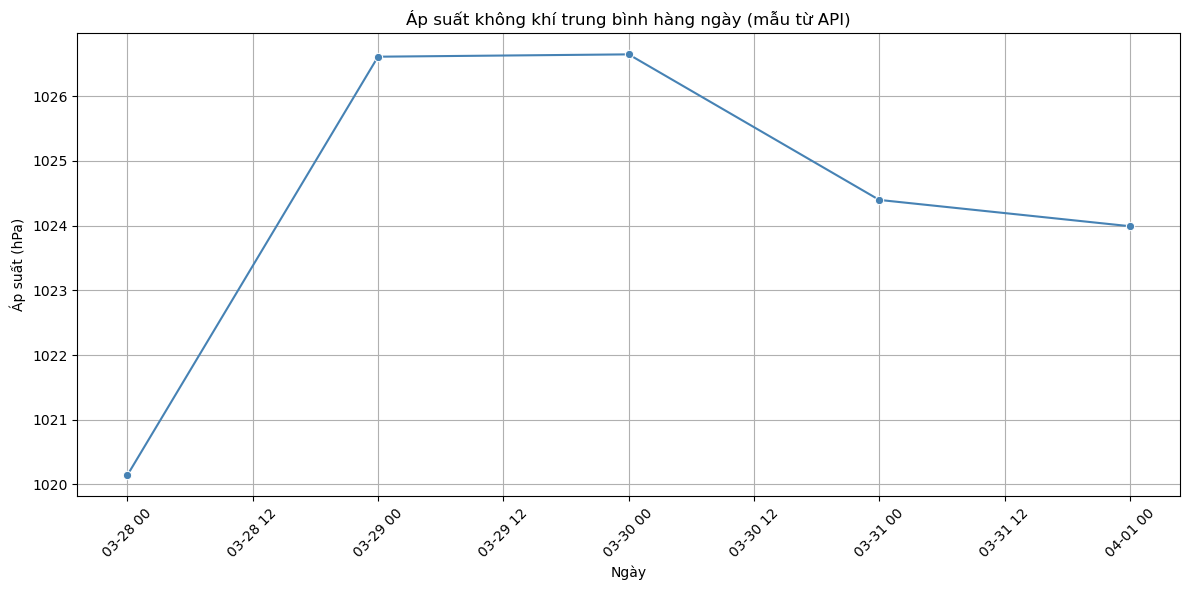

In [15]:
# Biểu đồ 1: Áp suất không khí theo từng ngày
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='avg_pressure', data=daily_summary_df, marker='o', color='steelblue')
plt.title('Áp suất không khí trung bình hàng ngày (mẫu từ API)')
plt.xlabel('Ngày')
plt.ylabel('Áp suất (hPa)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

b) Vẽ biểu đồ tốc độ gió (wind speed) theo từng ngày.

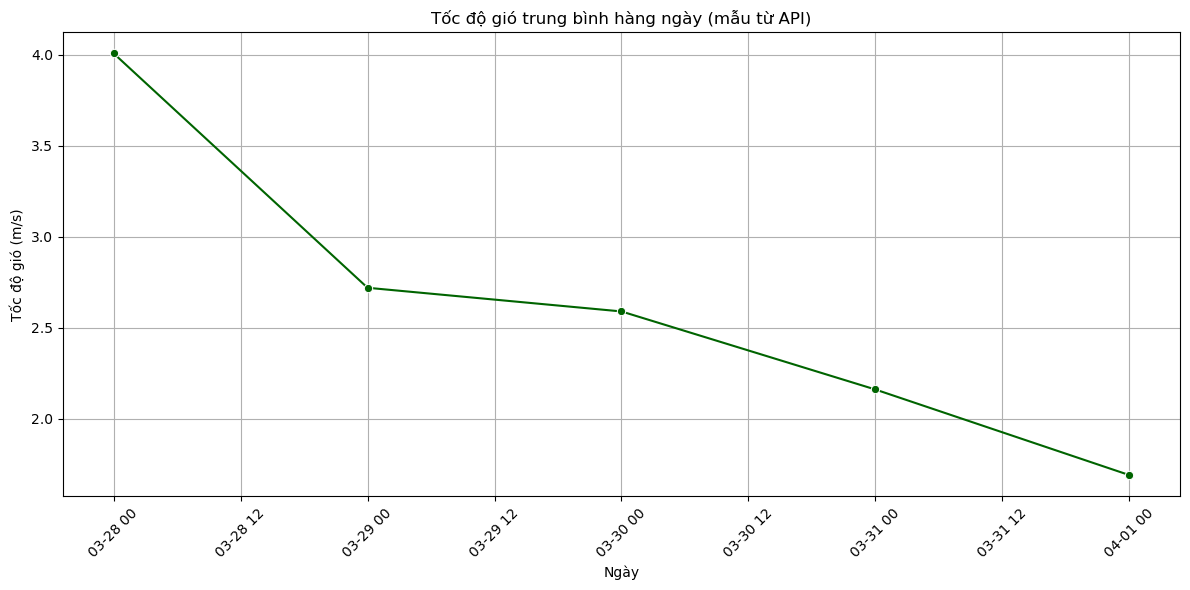

In [16]:
# Biểu đồ 2: Tốc độ gió theo từng ngày
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='avg_wind_speed', data=daily_summary_df, marker='o', color='darkgreen')
plt.title('Tốc độ gió trung bình hàng ngày (mẫu từ API)')
plt.xlabel('Ngày')
plt.ylabel('Tốc độ gió (m/s)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()